# Simple portfolio optimization: training, validation, testing

A CRRA investor with risk aversion $\gamma$ chooses the fraction $f$ of wealth to place in a single risky asset. End-of-period wealth (per dollar) is $1 + f\,m_t$ where $m_t = (r^{\text{Mkt}}_t - r^f_t)/(1 + r^f_t)$ is the risk-adjusted return, so the one-period problem is

$$
f^\star(\gamma) \;=\; \arg\max_{f} \; \mathbb{E}\bigl[u_\gamma(1 + f\,m)\bigr], \qquad u_\gamma(x) = \begin{cases} \log x & \gamma = 1 \\ \dfrac{x^{1-\gamma} - 1}{1-\gamma} & \gamma \neq 1 \end{cases}.
$$

This notebook parallels the training/validation/testing analysis of Section 11.8 in Myerson & Zambrano, using monthly Fama–French market data and three candidate return models (Normal, Student-$t$, Johnson $S_U$):

- **Training (fold 1, 1926-07 to 1982-12, $n = 678$).** Fit each candidate by MLE. Simulate $10^5$ draws from each fit (truncated below at $m = -0.6$), and compute the model-implied $f^\star(\gamma)$ for each $\gamma \in \{0.25, 0.5, 0.75, 1, 2, 3\}$.
- **Validation (fold 2, 1983-01 to 2012-12, $n = 360$).** For each $(\gamma, \text{model})$ pair, evaluate realized mean utility $\frac{1}{n_2}\sum_t u_\gamma(1 + f^\star_{\text{model}}\,m_t)$ on fold-2 returns. The winning model per $\gamma$ is the one whose $f^\star$ delivers the highest realized mean utility on data it has not seen. No scoring of the probability distributions themselves; selection is by the realized payoff of the decision the model implies.
- **Testing (post-2012, $n \approx 159$).** For $\gamma \in \{0.75, 1\}$, simulate the wealth path under each $\gamma$'s validation winner on realized test-set returns. Starting wealth $W_0 = 100{,}000$. With monthly data we have only about 13 calendar years of post-2012 returns; splitting them into two test folds would leave us underpowered to evaluate the strategy through a meaningful drawdown event, so we combine them into a single test fold.

**One technical refinement vs. the chapter.** For the optimizer we use the single-period $m_t$ formulation, which is algebraically correct for one-period expected utility. For the wealth-path simulations on real data we keep $r^{\text{Mkt}}_t$ and $r^f_t$ separate and use $W_{t+1} = W_t \cdot [1 + (1-f)\,r^f_t + f\,r^{\text{Mkt}}_t]$, so that the $(1-f)$ dollars earn the actual risk-free rate that prevailed that month rather than a constant. Once we are out of model-land, the fitted distributions and the $m_t$ compression no longer appear.

In [1]:
import numpy as np
import pandas as pd
import requests
from io import BytesIO
from zipfile import ZipFile
from scipy import stats
from scipy.optimize import minimize_scalar
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
rng = np.random.default_rng(607)

## Data and fold structure

Same Fama–French series and fold definitions as `1_fitting_and_selecting_one_asset.ipynb`. We keep both $m_t$ and the underlying $(r^{\text{Mkt}}_t, r^f_t)$ for each fold.

In [2]:
url = "https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/ftp/F-F_Research_Data_Factors_CSV.zip"
response = requests.get(url)
with ZipFile(BytesIO(response.content)) as zfile:
    csv_name = next(n for n in zfile.namelist() if n.lower().endswith(".csv"))
    with zfile.open(csv_name) as f:
        ff = pd.read_csv(f, skiprows=3, index_col=0)
ff = ff.apply(pd.to_numeric, errors="coerce").dropna()
ff = ff[ff.index.map(lambda s: s.isdigit() and len(s) == 6)]
ff["r_mkt"] = ff["Mkt-RF"] / 100 + ff["RF"] / 100
ff["r_f"]   = ff["RF"] / 100
ff["m"]     = (ff["r_mkt"] - ff["r_f"]) / (1 + ff["r_f"])

folds = {
    "training (fold 1)":   ff.loc["192607":"198212"],
    "validation (fold 2)": ff.loc["198301":"201212"],
    "test (folds 3+4)":    ff.loc["201301":],
}
pd.Series({k: len(v) for k, v in folds.items()}, name="n_obs")

training (fold 1)      678
validation (fold 2)    360
test (folds 3+4)       159
Name: n_obs, dtype: int64

## Training stage: fit three families on fold 1

In [3]:
train_m = folds["training (fold 1)"]["m"].values
families = {"Normal": stats.norm, "Student t": stats.t, "Johnson SU": stats.johnsonsu}
fits = {name: dist(*dist.fit(train_m)) for name, dist in families.items()}

pd.DataFrame({name: {"params": np.round(f.args + tuple(f.kwds.values()), 4)}
              for name, f in fits.items()}).T

,params
Normal,"[0.0064, 0.0587]"
Student t,"[3.4535, 0.0086, 0.0383]"
Johnson SU,"[0.2593, 1.2581, 0.0197, 0.0498]"


## Simulate $10^5$ draws from each fit, truncated at $m = -0.6$

Heavy sampling so rare events that the model puts probability on get a chance to show up. We then clip simulated draws below $m = -0.6$ — about twice the worst monthly market return ever observed in U.S. history ($\approx -0.30$, Sep 1931 / Oct 1987). The clip applies *only to the simulated draws used by the optimizer*; realized validation- and test-fold returns are used as-is. This stops the optimizer from being driven by tail regions that are physically impossible (e.g., Student-$t$ draws below $-1$, which would imply a single-month market loss of more than 100%).

In [4]:
n_simulations = 100_000
M_FLOOR = -0.6

child_seeds = rng.bit_generator._seed_seq.spawn(len(fits))
raw_draws = {name: f.rvs(size=n_simulations, random_state=np.random.default_rng(seed))
             for (name, f), seed in zip(fits.items(), child_seeds)}
draws = {name: np.maximum(x, M_FLOOR) for name, x in raw_draws.items()}

pd.DataFrame({
    name: {"m_min (raw)": raw_draws[name].min(),
           "m_max (raw)": raw_draws[name].max(),
           "# clipped at m=-0.6": int((raw_draws[name] < M_FLOOR).sum())}
    for name in fits
}).T.round(3)

,m_min (raw),m_max (raw),# clipped at m=-0.6
Normal,-0.242,0.260,0.0
Student t,-1.819,0.965,17.0
Johnson SU,-0.614,0.502,1.0


## Optimizer: CRRA expected utility in $m_t$-formulation

We maximize $\mathbb{E}[u_\gamma(1 + f\,m)]$ over $f \in [0, f_{\max}]$ with $f_{\max} = 5$ — an economic leverage cap (5× equity is well beyond any realistic borrowing arrangement). For draws with $1 + f\,m \le 0$, the CRRA utility is genuinely $-\infty$ (ruin), but a literal `-inf` breaks the optimizer's bracket search. We instead use a smooth floor: replace any non-positive wealth with a tiny positive value $\epsilon = 10^{-12}$ before applying $u_\gamma$, so ruin is finite-but-huge-negative and the mean utility is a continuous decreasing function of $f$ in the ruin region. With $10^5$ draws and unbounded-support fits, ruin draws can appear; the optimizer is then naturally pushed toward conservative $f$ — that is the whole point of heavy sampling.

In [5]:
F_MAX = 5.0
EPS = 1e-12

def neg_expected_utility(f, returns, gamma):
    w = np.maximum(1.0 + f * returns, EPS)
    u = np.log(w) if gamma == 1 else (w ** (1 - gamma) - 1) / (1 - gamma)
    return -u.mean()

def optimal_fraction(returns, gamma, f_max=F_MAX):
    res = minimize_scalar(neg_expected_utility, args=(returns, gamma),
                          bounds=(0.0, f_max), method="bounded",
                          options={"xatol": 1e-6})
    return res.x

## Training stage: $f^\star$ by model and risk aversion

In [6]:
gammas = [0.25, 0.5, 0.75, 1.0, 2.0, 3.0]
f_star = pd.DataFrame(
    {name: [optimal_fraction(x, g) for g in gammas] for name, x in draws.items()},
    index=pd.Index(gammas, name="gamma"),
).round(3)
f_star

,Normal,Student t,Johnson SU
gamma,,,
0.25,5.000,5.000,5.000
0.50,3.698,5.000,2.760
0.75,2.546,2.802,1.658
1.00,1.930,1.608,1.410
2.00,0.974,1.120,0.761
3.00,0.651,0.788,0.516


## Validation stage: evaluate the three $f^\star$ portfolios on fold-2 realized returns

For each $(\gamma, \text{model})$ pair, realized mean utility on the 360 fold-2 observations,
$\frac{1}{n_2}\sum_{t \in \text{fold 2}} u_\gamma(1 + f^\star_{\text{model}}\,m_t)$.
Higher is better. The winning model per row is bolded.

In [7]:
val_m = folds["validation (fold 2)"]["m"].values

def realized_mean_utility(f, m, gamma):
    w = 1.0 + f * m
    if np.any(w <= 0):
        return -np.inf
    return (np.log(w) if gamma == 1 else (w ** (1 - gamma) - 1) / (1 - gamma)).mean()

val_table = pd.DataFrame(
    {name: [realized_mean_utility(f_star.loc[g, name], val_m, g) for g in gammas]
     for name in fits},
    index=pd.Index(gammas, name="gamma"),
)
winners = val_table.idxmax(axis=1).rename("winner")
pd.concat([val_table.round(5), winners], axis=1)

,Normal,Student t,Johnson SU,winner
gamma,,,,
0.25,-inf,-inf,-inf,Normal
0.50,0.01432,-inf,0.01240,Normal
0.75,0.00994,0.01027,0.00776,Student t
1.00,0.00756,0.00689,0.00635,Normal
2.00,0.00383,0.00404,0.00335,Student t
3.00,0.00257,0.00275,0.00226,Student t


Things to look for:

1. **The winning model can differ from the CRPS winner.** In notebook 1 Johnson $S_U$ won CRPS on fold 2 by a hair (0.02449 vs. Student-$t$ 0.02452 vs. Normal 0.02527). Decision-payoff selection here often disagrees because CRPS scores bulk fit while the portfolio decision is tail-sensitive.
2. **Ruin shows up explicitly.** At very low $\gamma$ all three models recommend $f^\star$ near the economic cap $f_{\max} = 5$, and the worst fold-2 month (October 1987, $m = -0.231$) bankrupts the portfolio at $f \gtrsim 1/0.231 \approx 4.33$. Realized mean utility is $-\infty$, which is the right answer: the recommendation is operationally unusable on this validation period.
3. **Conservative isn't always better.** Student-$t$'s fitted $df \approx 3.45$ anticipates a much heavier left tail than fold 2 actually delivered; even fold 2's worst month is *milder* than what the Student-$t$ thinks is plausible. The result is that for moderate $\gamma$, Student-$t$'s more conservative $f^\star$ leaves growth on the table relative to the Normal, even though the Normal is statistically wrong about the bulk fit. The decision-payoff selection rewards whichever model best matches the *realized* validation period — not whichever has the most economically defensible tail.

For the test stage we proceed with the **$\gamma = 1$ winner** (the log-utility / Kelly case).

## Wealth paths on fold 2 for the $\gamma \in \{0.75, 1\}$ winners

Same wealth-evolution equation as the test stage will use:
$W_{t+1} = W_t \cdot [1 + (1 - f)\,r^f_t + f\,r^{\text{Mkt}}_t]$
with realized $r^{\text{Mkt}}_t$ and $r^f_t$ from fold 2. These are the paths each winning model's $f^\star$ would have produced over 1983–2012 had we been able to trade them. We will compare them directly against the test-set paths to illustrate the **winner's curse**: the validation-stage performance overstates real-world performance because we selected the model that did best on this specific fold.

In [8]:
def wealth_path(fold_df, f, W0=100_000.0):
    r_mkt = fold_df["r_mkt"].values
    r_f   = fold_df["r_f"].values
    gross = 1.0 + (1.0 - f) * r_f + f * r_mkt
    wealth = W0 * np.concatenate([[1.0], np.cumprod(gross)])
    raw = [pd.Timestamp(f"{s[:4]}-{s[4:]}-01") + pd.offsets.MonthEnd(0) for s in fold_df.index]
    dates = pd.DatetimeIndex([raw[0] - pd.offsets.MonthEnd(1)] + raw)
    return dates, wealth

def path_summary(wealth, W0=100_000.0):
    n_months = len(wealth) - 1
    n_years = n_months / 12
    terminal = wealth[-1]
    annualized = (terminal / W0) ** (1 / n_years)
    max_dd = (wealth / np.maximum.accumulate(wealth) - 1).min()
    return {
        "starting wealth": f"${W0:,.0f}",
        "terminal wealth": f"${terminal:,.0f}",
        "annualized growth ratio": round(annualized, 4),
        "max drawdown": f"{max_dd:.1%}",
        "n_months": n_months,
    }

test_gammas = [0.75, 1.0]
winning_models = {g: winners.loc[g] for g in test_gammas}
f_winners = {g: f_star.loc[g, winning_models[g]] for g in test_gammas}

val_paths = {g: wealth_path(folds["validation (fold 2)"], f_winners[g]) for g in test_gammas}

val_summary = pd.DataFrame({
    f"gamma={g}, {winning_models[g]}, f*={f_winners[g]:.3f}": path_summary(val_paths[g][1])
    for g in test_gammas
})
val_summary

,"gamma=0.75, Student t, f*=2.802","gamma=1.0, Normal, f*=1.930"
starting wealth,"$100,000","$100,000"
terminal wealth,"$6,161,001","$5,368,785"
annualized growth ratio,1.1472,1.142
max drawdown,-92.8%,-77.3%
n_months,360,360


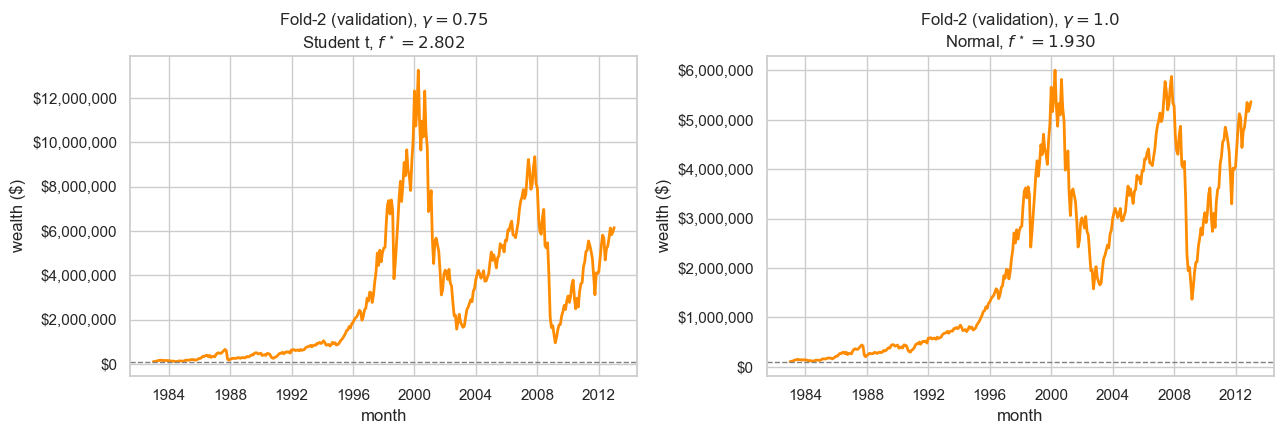

In [9]:
fig, axes = plt.subplots(1, len(test_gammas), figsize=(13, 4.5), sharey=False)
for ax, g in zip(axes, test_gammas):
    dates_v, wealth_v = val_paths[g]
    ax.plot(dates_v, wealth_v, lw=2, color="darkorange")
    ax.axhline(100_000.0, color="0.5", ls="--", lw=1)
    ax.set(title=f"Fold-2 (validation), $\\gamma = {g}$\n{winning_models[g]}, $f^\\star = {f_winners[g]:.3f}$",
           xlabel="month", ylabel="wealth ($)")
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x:,.0f}"))
plt.tight_layout()
plt.show()

## Test stage: wealth paths on the combined post-2012 fold

Same wealth-evolution equation, now on the test fold (2013-01 onward, $n = 158$ months) that played no role in fitting or selection. The test period includes the March 2020 COVID drawdown, the 2022 bear market, and the 2018 Q4 selloff — i.e., it is not a uniformly benign sample. We then compare against the fold-2 paths to read off the winner's curse.

In [10]:
test_paths = {g: wealth_path(folds["test (folds 3+4)"], f_winners[g]) for g in test_gammas}

comparison = pd.DataFrame({
    (f"gamma={g}, {winning_models[g]}, f*={f_winners[g]:.3f}", stage):
        path_summary(path[1])
    for g in test_gammas
    for stage, path in [("fold 2 (validation)", val_paths[g]), ("test (folds 3+4)", test_paths[g])]
})
comparison.columns = pd.MultiIndex.from_tuples(comparison.columns)
comparison

gamma=0.75, Student t, f*=2.802                   \
                                    fold 2 (validation) test (folds 3+4)   
starting wealth                                $100,000         $100,000   
terminal wealth                              $6,161,001       $4,148,607   
annualized growth ratio                          1.1472           1.3247   
max drawdown                                     -92.8%           -60.5%   
n_months                                            360              159   

                        gamma=1.0, Normal, f*=1.930                   
                                fold 2 (validation) test (folds 3+4)  
starting wealth                            $100,000         $100,000  
terminal wealth                          $5,368,785       $1,799,479  
annualized growth ratio                       1.142           1.2437  
max drawdown                                 -77.3%           -44.9%  
n_months                                        360              159

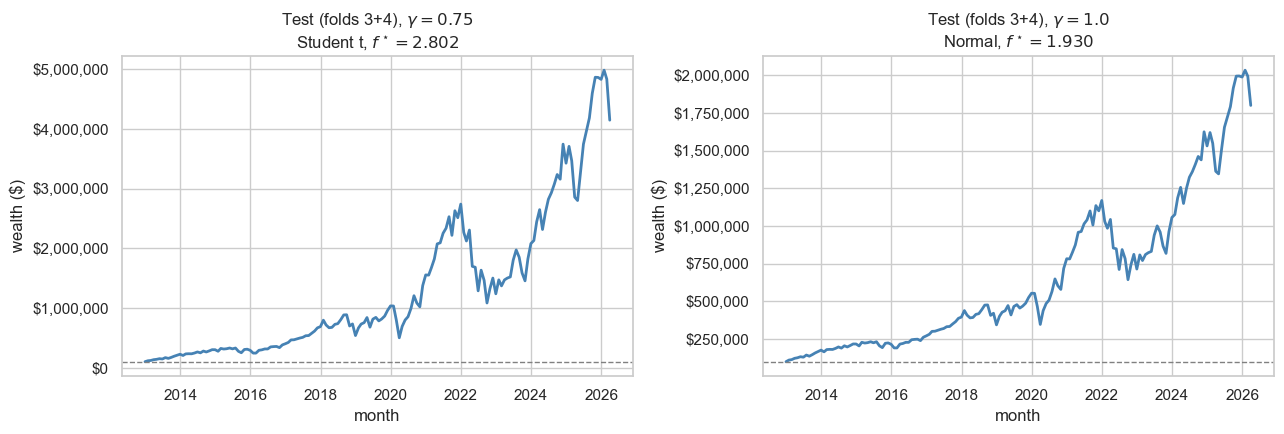

In [11]:
fig, axes = plt.subplots(1, len(test_gammas), figsize=(13, 4.5), sharey=False)
for ax, g in zip(axes, test_gammas):
    dates_t, wealth_t = test_paths[g]
    ax.plot(dates_t, wealth_t, lw=2, color="steelblue")
    ax.axhline(100_000.0, color="0.5", ls="--", lw=1)
    ax.set(title=f"Test (folds 3+4), $\\gamma = {g}$\n{winning_models[g]}, $f^\\star = {f_winners[g]:.3f}$",
           xlabel="month", ylabel="wealth ($)")
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x:,.0f}"))
plt.tight_layout()
plt.show()

## Caveats for class discussion

**Winner's curse — and what we actually see here.** The fold-2 statistics belong to the strategies that *won* the validation race at each $\gamma$. By construction, those strategies were selected because they did best on fold 2 — so their fold-2 performance is an *upward-biased* estimate of how they will do on data they have never seen. Chapter 11.8's expectation: the test fold should look *worse* than the validation fold.

In our table, the picture is mixed and worth unpacking. The test-stage **annualized growth ratios are higher** than validation (32.5% vs. 14.7% at $\gamma = 0.75$; 24.4% vs. 14.2% at $\gamma = 1$), but the test stage also delivers serious drawdowns (−60.5% at $\gamma = 0.75$, −44.9% at $\gamma = 1$) — March 2020 and the 2022 bear market are real bites taken out of levered portfolios. The story is: the post-2012 sample has a strong bull-market drift that dominates the growth-ratio statistic, but the drawdown statistic is sample-dependent in the other direction. Why doesn't the validation-vs.-test comparison clearly show the curse? Two reasons. First, fold 2 includes three major bear markets (1987, 2000-2002, 2008) while the test fold includes only one and a half (2020, 2022); so even though the validation strategy was selected to do best on fold 2, fold 2's own bear-market burden depresses *its* statistics too. Second, $n = 159$ is small; sampling noise on this scale is substantial. A test fold that included a 1929- or 2008-class event would likely show the canonical pattern.

**The drawdown numbers are large because $f^\star > 1$.** At $\gamma = 0.75$, the Student-$t$ winner recommends $f^\star = 2.802$ — nearly 3× leverage. The 2008 drawdown of the unlevered market was about $-50\%$; at $f \approx 2.8$ the corresponding portfolio drawdown is much worse (and the algebra is not linear because $r^f$ and compounding matter). This is the leverage cost of having low $\gamma$.

**No refinement after the test.** If we now look at the test wealth paths, think "I bet a different $\gamma$ or a different model would have looked even better," and re-run, we have spent the test set. There is no further held-out fold to fall back on.

**Truncation at $m = -0.6$.** We capped simulated draws below at $-0.6$ — twice the worst monthly market return ever observed ($\approx -0.30$). This is a modeling choice: it prevents Student-$t$'s fitted $df \approx 3.45$ tail from producing $m < -1$ draws that the optimizer would otherwise take seriously. Realized validation- and test-fold returns are used as-is; the cap applies only to the model-generated draws used during optimization. Without this cap Student-$t$ would recommend a much more conservative $f^\star$, but the conservativeness would be paying for tail outcomes that cannot physically occur.

**Borrowing rate above $r^f$.** The wealth-evolution equation uses the same $r^f_t$ for the lending leg $(1-f)\,r^f_t$ and (implicitly, when $f > 1$) for the borrowing leg. In practice retail and institutional investors face a borrowing rate strictly above $r^f$ (margin rates, repo haircuts, prime-broker spreads). The honest version uses a piecewise rate that bites when $f > 1$ and shrinks the realized return whenever the strategy is levered. This would push down both the validation-stage utility for high-$f^\star$ models and the test-set growth rate.